11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 238ms/step - loss: 0.1287 - val_loss: 0.0815
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 232ms/step - loss: 0.0790 - val_loss: 0.0760
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - loss: 0.0753 - val_loss: 0.0734
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - loss: 0.0733 - val_loss: 0.0720
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 234ms/step - loss: 0.0721 - val_loss: 0.0709
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


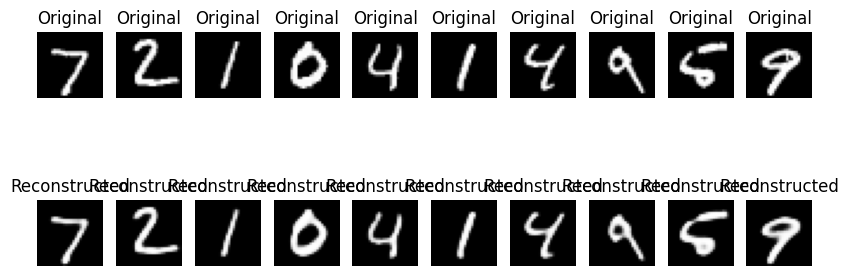

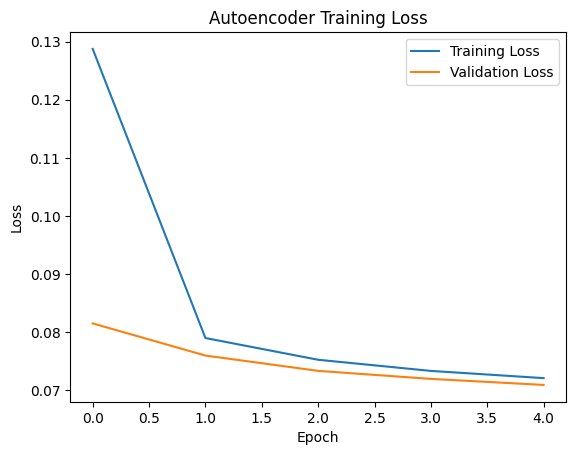

In [ ]:
# BY Vladlen Rebello | PRN: 23070521170

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# 1. Load MNIST dataset
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# 2. Normalize and reshape images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. Build Encoder
input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2, 2), padding="same")(x)
x = Conv2D(16, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)

# 4. Build Decoder
x = Conv2D(16, (3, 3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# 5. Create Autoencoder
autoencoder = Model(input_img, decoded)

# 6. Compile
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# 7. Train
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, X_test)
)

# 8. Reconstruct test images
reconstructed = autoencoder.predict(X_test)

# 9. Compare original and reconstructed images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")

plt.show()

# 10. Plot training loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()